# F_basic_ephys.ipynb

## Purpose
Comprehensive characterization of electrophysiological unit properties across all recorded neurons. Analyzes baseline and response firing rates, burst properties (ACG fit parameters), waveform features, and opto-tagging quality. Fits OLS models examining how intrinsic properties predict the degree of outcome vs. action coding.

## Manuscript figure panels
- FigA15 d-f

## Prerequisites
Before running this notebook, ensure the figure preparation scripts have been run in sequence (see `/root/capsule/code/beh_ephys_analysis/session_combine/figure_preparation/sequence`).

Required input files:
- `combined_unit_tbl.pkl` (Step 1)
- `combined_basic_ephys.pkl` (Step 5)
- `combined_acg.pkl` (Step 7)

In [1]:
import sys
import os
from matplotlib.colors import LinearSegmentedColormap
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import os
import sys
_beh_ephys_root = os.path.normpath(os.path.join(os.getcwd(), '..', '..'))
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
from pathlib import Path
import glob
import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb
from utils.ephys_functions import*
from utils.ccf_utils import ccf_pts_convert_to_mm, pir_to_lps, project_to_plane
from utils.combine_tools import apply_qc, to_str_intlike, spatial_dependence_summary, binary_shift_P_vs_U, welch_shift_P_vs_U
import pickle
import scipy.stats as stats
import spikeinterface as si
import shutil
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score
import warnings
from scipy.stats import gaussian_kde
import trimesh
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from utils.ccf_utils import ccf_pts_convert_to_mm
from utils.capsule_migration import capsule_directories
from trimesh import load_mesh
from scipy.stats import pearsonr
import statsmodels.api as sm
from aind_ephys_utils import align
import k3d
from scipy.stats import rankdata
from scipy.ndimage import binary_dilation
from skimage.measure import find_contours
from joblib import Parallel, delayed
warnings.filterwarnings('ignore')
capsule_dirs = capsule_directories()

%matplotlib inline
from utils.capsule_migration import CAPSULE_ROOT
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df


## Setup and Data Loading

Import libraries, set up paths, and load all required data files including basic ephys metrics, ACG fit parameters, unit tables, and quality control criteria.

In [2]:
# load basic ephys
target_folder = f'{capsule_dirs["manuscript_fig_dir"]}/F_basic_ephys'
if not os.path.exists(target_folder):
    os.makedirs(target_folder)
be_folder = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'basic_ephys')
be_file = os.path.join(be_folder, f'basic_ephys.pkl')
with open(be_file, 'rb') as f:
    basic_ephys_df = pickle.load(f)
filter = basic_ephys_df['be_filter'].values
filter = np.array(filter, dtype=bool)
basic_ephys_df['be_filter'] = filter
basic_ephys_df.rename(columns={'unit': 'unit_id'}, inplace=True)
basic_ephys_df['unit_id'] = basic_ephys_df['unit_id'].apply(to_str_intlike)

In [3]:
# load parameters for acg
fit_params_file = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'acg', 'acf_fit_parameters_with_pcs.csv')
fit_params_df = pd.read_csv(fit_params_file)
fit_params_mat_file = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'acg', 'acf_fit_parameters_and_components.pkl')
with open(fit_params_mat_file, 'rb') as f:
    fit_data = pickle.load(f)
C1_mat = fit_data['C1_mat']
C2_mat = fit_data['C2_mat']
C3_mat = fit_data['C3_mat']
auto_corr = fit_data['acg_mat']
# add_auto_corr to df
fit_params_df['C1'] = C1_mat.tolist()  # convert numpy array to list for storage in DataFrame
fit_params_df['C2'] = C2_mat.tolist()  # convert numpy array to list for storage in DataFrame
fit_params_df['C3'] = C3_mat.tolist()  # convert numpy array to list for storage in DataFrame
fit_params_df['auto_corr'] = auto_corr.tolist()  # convert numpy array to list for storage in DataFrame

In [4]:
with open(os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'combined_unit_tbl', 'combined_unit_tbl.pkl'), 'rb') as f:
    combined_tagged_units = pickle.load(f)
combined_tagged_units.rename(columns={'unit': 'unit_id'}, inplace=True)
# exlcude units from excluded sessions
combined_tagged_units['unit_id'] = combined_tagged_units['unit_id'].apply(to_str_intlike)
# antidromic data
version = 'PrL_S1'
antidromic_file = f'{capsule_dirs["manuscript_fig_prep_dir"]}/antidromic_analysis/{version}/combined_antidromic_results.pkl'
with open(antidromic_file, 'rb') as f:
    antidromic_df = pickle.load(f)

antidromic_df.rename(columns={'unit': 'unit_id'}, inplace=True)
antidromic_df['unit_id'] = antidromic_df['unit_id'].apply(to_str_intlike)
antidromic_df = antidromic_df[['unit_id', 'session', 'p_auto_inhi', 't_auto_inhi',
       'p_collision', 't_collision', 'p_antidromic', 't_antidromic', 'tier_1',
       'tier_2', 'tier_1_long', 'tier_2_long']].copy()
combined_tagged_units = combined_tagged_units.merge(antidromic_df, on=['session', 'unit_id'], how='left')
combined_tagged_units['tier_1'] = combined_tagged_units['tier_1'].fillna(False)
combined_tagged_units['tier_2'] = combined_tagged_units['tier_2'].fillna(False)
combined_tagged_units['tier_1_long'] = combined_tagged_units['tier_1_long'].fillna(False)
combined_tagged_units['tier_2_long'] = combined_tagged_units['tier_2_long'].fillna(False)


Applying conditional bounds for isi_violations
 - isi_violations: 15278 -> 6737 units passed
Applying items for qc_pass: [True]
 - qc_pass: 6737 -> 4497 units passed
Applying bounds for peak: [-1000, 500]
 - peak: 4497 -> 4474 units passed
 - sd: 4474 -> 4474 units passed
Applying conditional bounds for y_loc
 - y_loc: 4474 -> 3179 units passed
Applying opto conditions: ['p_max', 'eu', 'corr', 'tag_loc', 'lat_max_p', 'p_mean', 'sig_counts']


Number of opto rows after filtering: 299
Number of non-opto rows after filtering: 3179


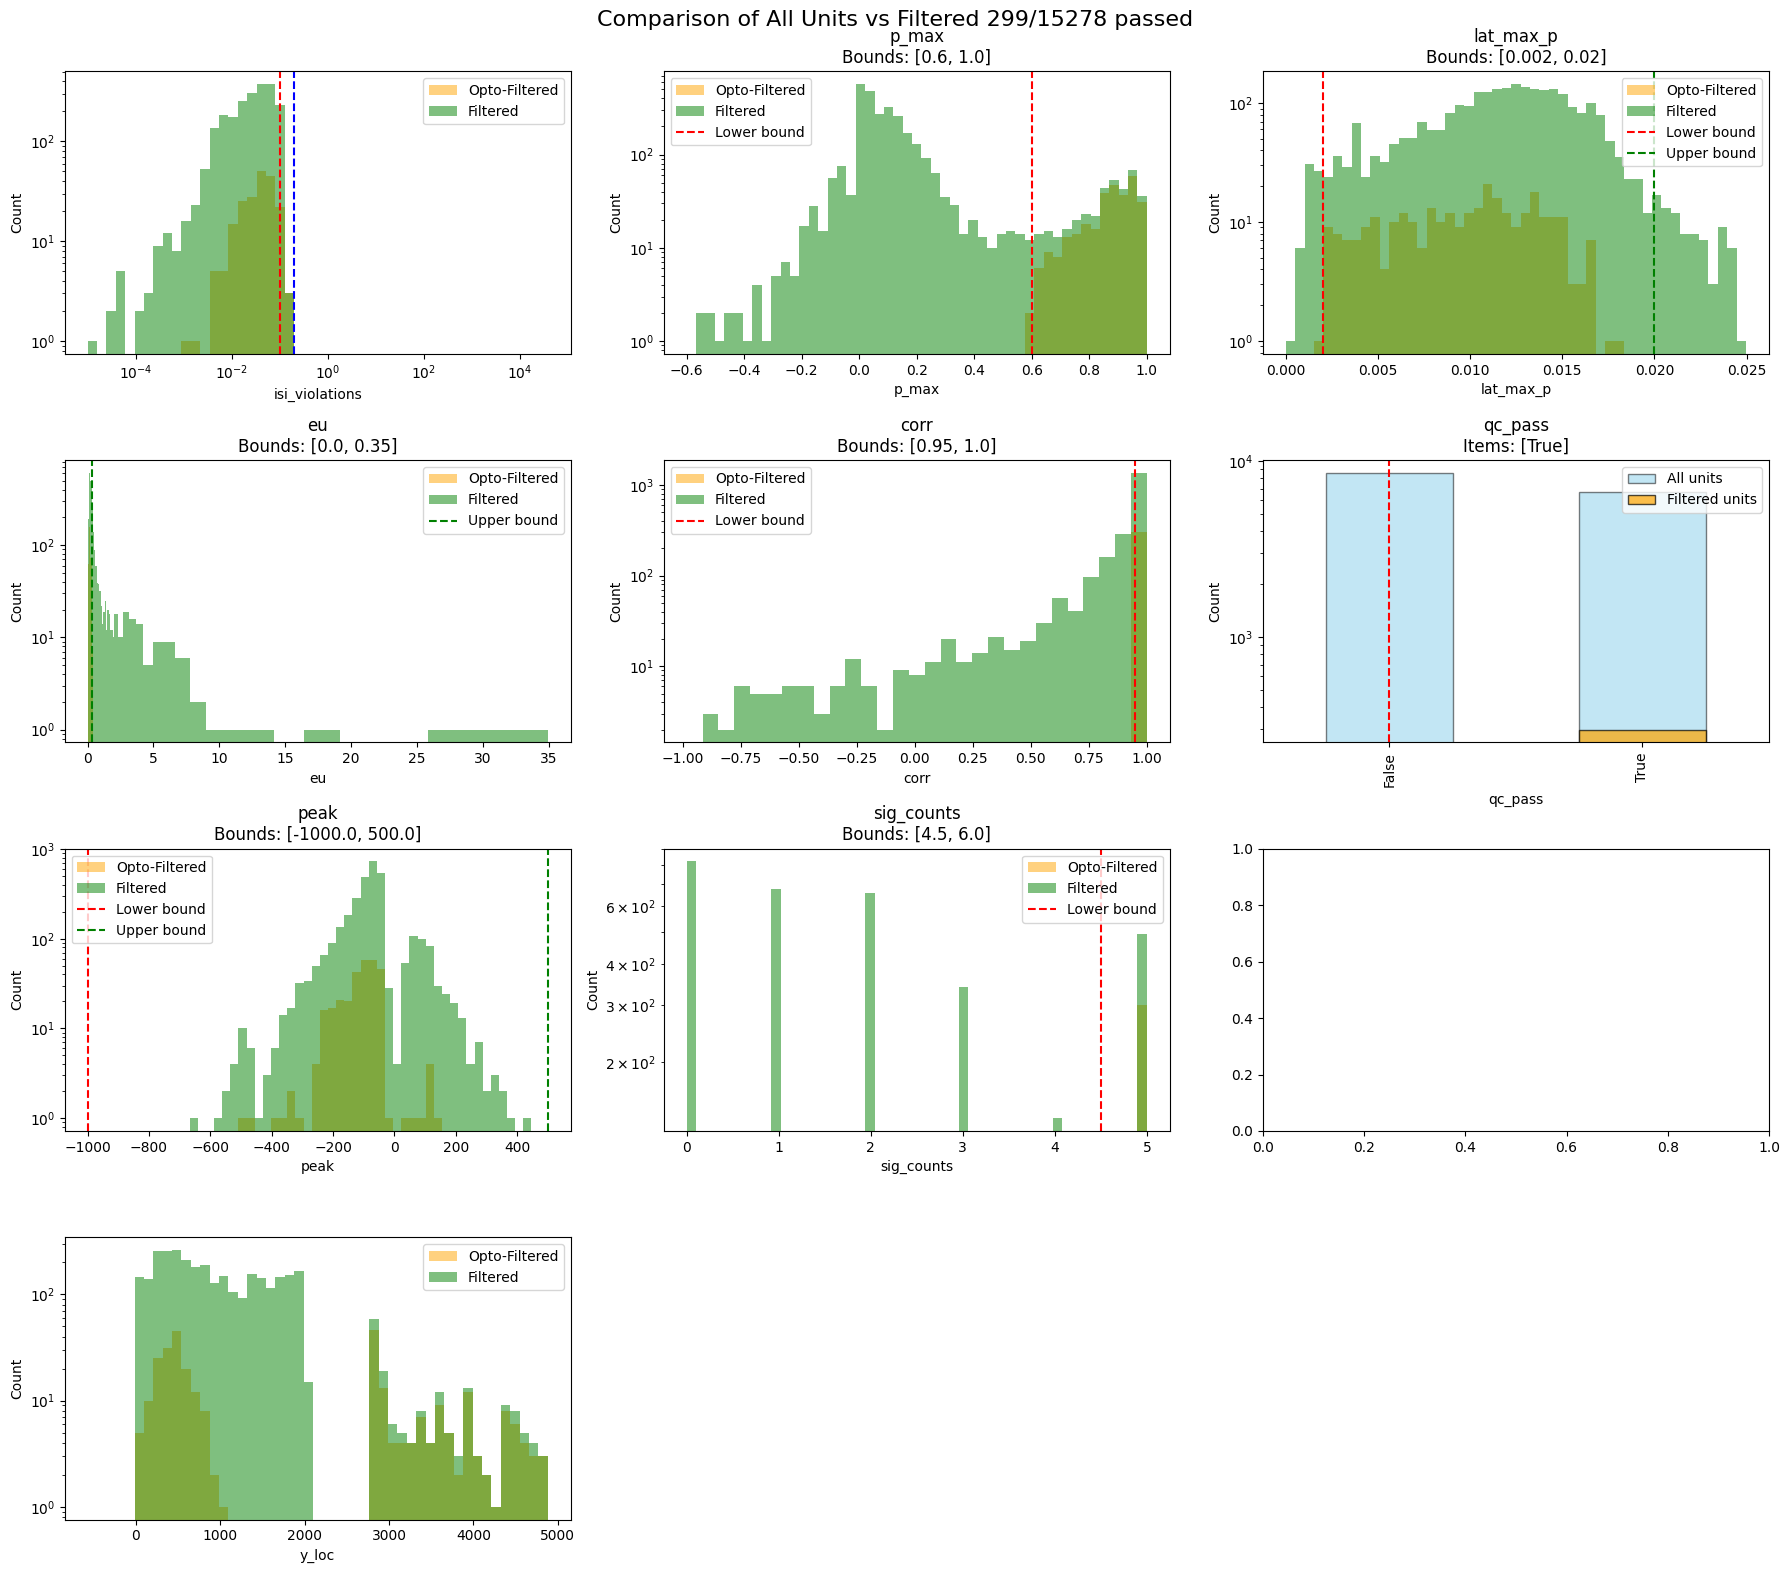

In [5]:
density = False
criteria_name = 'basic_ephys_all'
with open(os.path.join(CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics', f'{criteria_name}.json'), 'r') as f:
    constraints = json.load(f)
constraints['sd'] = [0, 1]
combined_tagged_units_filtered, combined_tagged_units, fig, axes = apply_qc(combined_tagged_units, constraints, density=density, plot_all=False, plot_half=True)
combined_tagged_units.rename(columns={'unit': 'unit_id'}, inplace=True)
combined_tagged_units['unit_id'] = combined_tagged_units['unit_id'].apply(to_str_intlike)
combined_tagged_units_filtered.rename(columns={'unit': 'unit_id'}, inplace=True)
combined_tagged_units_filtered['unit_id'] = combined_tagged_units_filtered['unit_id'].apply(to_str_intlike)
fig.savefig(fname=os.path.join(target_folder, f'unit_quality_metrics_summary_density_{density}.pdf'))
fig.savefig(fname=os.path.join(target_folder, f'unit_quality_metrics_summary_density_{density}.svg'))

## Quality Control and Unit Selection

Apply quality control filters to select high-quality units and visualize unit quality metrics including Euclidean distance and correlation histograms for opto-tagged vs non-tagged units.

In [6]:
combined_tagged_units_good = combined_tagged_units[combined_tagged_units['selected_qc_only']].copy().reset_index(drop=True)

['/root/capsule/scratch/results/manuscript/figures/F_basic_ephys/FigureS13f_bottomleft_euclidean_distance_histogram.csv']

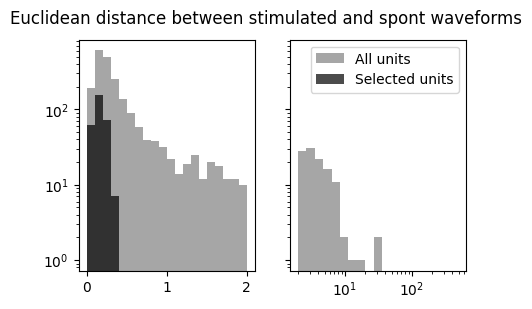

In [7]:
# plot euclidean distance histogram, with linear bins from 0 to boundary, and log bins larger than that
col = 'eu'
boundary = 2
tag_color = 'k'
nontag_color = 'gray'
edges_small = np.arange(0, boundary+0.1, 0.1)
edges_large = np.logspace(np.log10(boundary), np.log10(combined_tagged_units[col].max()), 20)
fig, axes = plt.subplots(1, 2, figsize=(5, 3), sharey=True)
ax = axes[0]
ax.hist(combined_tagged_units_good[col], bins=edges_small, color=nontag_color, alpha=0.7)
ax.hist(combined_tagged_units_filtered[col], bins=edges_small, color=tag_color, alpha=0.7)
ax.set_yscale('log')
ax = axes[1]
ax.hist(combined_tagged_units_good[col], bins=edges_large, color=nontag_color, alpha=0.7)
ax.hist(combined_tagged_units_filtered[col], bins=edges_large, color=tag_color, alpha=0.7)
ax.set_xscale('log')
ax.set_yscale('log')
plt.suptitle('Euclidean distance between stimulated and spont waveforms')
plt.legend(['All units', 'Selected units'])
save_panels(fig, target_folder, f'euclidean_distance_histogram', ['FigureS13f_bottomleft'], exts=('pdf',))
# ---- panel CSV (rule 8 histogram: all vs selected units) ----
save_panel_csv(columns_to_df(**{f'{col}_all': combined_tagged_units_good[col].dropna().values, f'{col}_selected': combined_tagged_units_filtered[col].dropna().values}), target_folder, f'euclidean_distance_histogram', ['FigureS13f_bottomleft'])
###FigureS13f_bottomleft### dont't separate panels for histogram data save. Just one all good unit, one opto-tagged unit 

['/root/capsule/scratch/results/manuscript/figures/F_basic_ephys/FigureS13f_bottomright_correlation_histogram.csv']

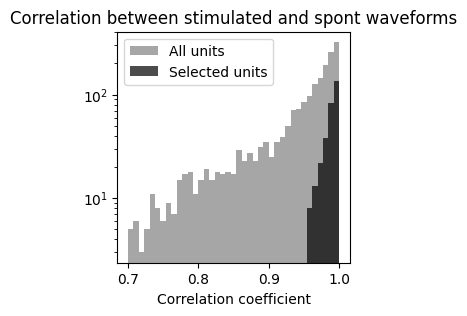

In [8]:
# plot euclidean distance histogram, with linear bins from 0 to boundary, and log bins larger than that
col = 'corr'
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
edges = np.linspace(0.7, 1, 40)
ax.hist(combined_tagged_units_good[col], bins=edges, color=nontag_color, alpha=0.7);
ax.hist(combined_tagged_units_filtered[col], bins=edges, color=tag_color, alpha=0.7);
ax.set_yscale('log')
plt.title('Correlation between stimulated and spont waveforms')
ax.set_xlabel('Correlation coefficient')
plt.legend(['All units', 'Selected units'])
save_panels(fig, target_folder, f'correlation_histogram', ['FigureS13f_bottomright'], exts=('pdf',))
# ---- panel CSV (rule 8 histogram: all vs selected units) ----
save_panel_csv(columns_to_df(**{f'{col}_all': combined_tagged_units_good[col].dropna().values, f'{col}_selected': combined_tagged_units_filtered[col].dropna().values}), target_folder, f'correlation_histogram', ['FigureS13f_bottomright'])
###FigureS13f_bottomright###

['/root/capsule/scratch/results/manuscript/figures/F_basic_ephys/FigureS13f_topleft_ISI_histogram.csv']

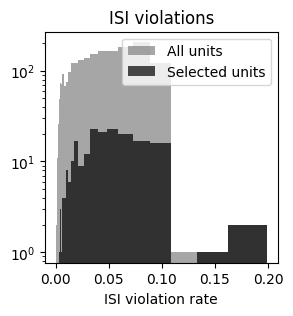

In [9]:
# plot ISI violation
col = 'isi_violations'
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
edges = np.logspace(np.log10(1e-5), np.log10(np.nanmax(combined_tagged_units_good[col])), 50)
ax.hist(combined_tagged_units_good[col], bins=edges, color=nontag_color, alpha=0.7);
ax.hist(combined_tagged_units_filtered[col], bins=edges, color=tag_color, alpha=0.7);
ax.set_yscale('log')
plt.title('ISI violations')
ax.set_xlabel('ISI violation rate')
plt.legend(['All units', 'Selected units'])
save_panels(fig, target_folder, f'ISI_histogram', ['FigureS13f_topleft'], exts=('pdf',))
# ---- panel CSV (rule 8 histogram: all vs selected units) ----
save_panel_csv(columns_to_df(**{f'{col}_all': combined_tagged_units_good[col].dropna().values, f'{col}_selected': combined_tagged_units_filtered[col].dropna().values}), target_folder, f'ISI_histogram', ['FigureS13f_topleft'])
###FigureS13f_topleft### 

['/root/capsule/scratch/results/manuscript/figures/F_basic_ephys/FigureS13f_topright_peak_histogram.csv']

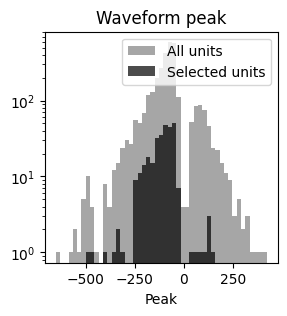

In [10]:
# plot waveform peak
col = 'peak'
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
edges = np.linspace(np.nanmin(combined_tagged_units_good[col]), np.nanmax(combined_tagged_units_good[col]), 50)
ax.hist(combined_tagged_units_good[col], bins=edges, color=nontag_color, alpha=0.7);
ax.hist(combined_tagged_units_filtered[col], bins=edges, color=tag_color, alpha=0.7);
ax.set_yscale('log')
plt.title('Waveform peak')
ax.set_xlabel('Peak')
plt.legend(['All units', 'Selected units'])
save_panels(fig, target_folder, f'peak_histogram', ['FigureS13f_topright'], exts=('pdf',))
# ---- panel CSV (rule 8 histogram: all vs selected units) ----
save_panel_csv(columns_to_df(**{f'{col}_all': combined_tagged_units_good[col].dropna().values, f'{col}_selected': combined_tagged_units_filtered[col].dropna().values}), target_folder, f'peak_histogram', ['FigureS13f_topright'])
###FigureS13f_topright### 

In [11]:
# load and add model variables
beh_folder = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'outcome_regressions')
model_combined = pd.read_csv(os.path.join(beh_folder, 'model_combined_beh_all.csv'), index_col=0)
model_combined['theta'] = model_combined['theta'] - 0.5
model_combined['unit_id'] = model_combined['unit_id'].apply(to_str_intlike)

versions = ['e', 'l', 'com']
for version in versions:
    all_vec = np.column_stack((
        model_combined[f'coef_outcome_{version}_mc'],
        model_combined[f'coef_Qchosen_{version}_ori']
    ))
    theta, rho = np.arctan2(all_vec[:, 1], all_vec[:, 0]), np.hypot(all_vec[:, 1], all_vec[:, 0])
    bound_1, bound_2, bound_3 = -(1 / 4) * np.pi, np.pi, -np.pi
    theta_scaled_dis = np.zeros_like(theta)
    for ind, angle_curr in enumerate(theta):
        if bound_1 < angle_curr <= bound_2:
            theta_scaled_dis[ind] = (angle_curr - bound_1) / (bound_2 - bound_1)
        else:
            theta_scaled_dis[ind] = (bound_1 - angle_curr) / (bound_1 - bound_3)
    theta_scaled_dis_all = 1 - theta_scaled_dis - 0.5
    model_combined[f'theta_{version}'] = theta_scaled_dis_all

# derived features
model_combined['coef_outcome|(|coef_outcome| + |coef_Q|)'] = (
    model_combined['coef_outcome_com_mc'] /
    (np.abs(model_combined['coef_outcome_com_mc']) + np.abs(model_combined['coef_Qchosen_com_mc']))
)
model_combined['outcome_ipsi'] = (
    model_combined['coef_outcome_com_mc'] + model_combined['coef_outcome:ipsi_com_mc']
)
model_combined['outcome_contra'] = (
    model_combined['coef_outcome_com_mc'] - model_combined['coef_outcome:ipsi_com_mc']
)

response_tbl = pd.read_csv(os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'response_regression', 'response_ratio_beh_all_go_cue.csv'))
response_tbl['unit_id'] = response_tbl['unit'].apply(to_str_intlike)


In [12]:
features_combined = basic_ephys_df.merge(combined_tagged_units_filtered[['session', 'unit_id', 'sex', 'x_ccf', 'y_ccf', 'z_ccf']], on=['session', 'unit_id'], how='inner')
features_combined = features_combined.merge(model_combined, on=['session', 'unit_id'], how='left')
features_combined = features_combined.merge(response_tbl, on=['session', 'unit_id'], how='left')

In [13]:
# load waveforms and merge
waveform_file = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'waveforms_np', 'combined_features.csv')
wf_combined_features = pd.read_csv(waveform_file)
wf_combined_features.rename(columns={'unit': 'unit_id'}, inplace=True)
wf_combined_features['unit_id'] = wf_combined_features['unit_id'].apply(to_str_intlike)
features_combined = features_combined.merge(wf_combined_features, on=['session', 'unit_id'], how='left')
features_combined = features_combined.merge(fit_params_df, on=['session', 'unit_id'], how='left')

## Feature Integration

Merge basic ephys features with behavioral model results, waveform features, and anatomical coordinates to create a comprehensive feature matrix for downstream analyses.

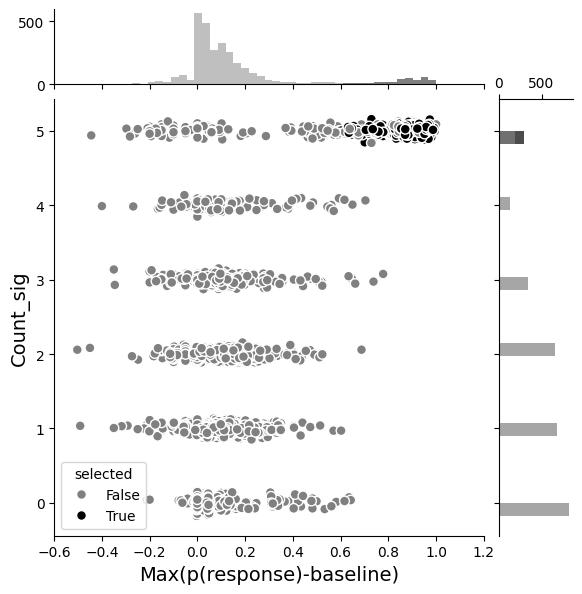

In [14]:

# opto tagged vs not
# Define color palette for groups
palette = {True: "k", False: "gray"}
x_col = 'p_max'
y_col = 'sig_counts'

combined_tagged_units_plot = combined_tagged_units.copy()
combined_tagged_units_plot[y_col] = combined_tagged_units_plot[y_col]  + np.random.normal(0, 0.05, size=len(combined_tagged_units_plot[y_col]))  # add jitter to y-axis for better visibility

# Create JointGrid
g = sns.JointGrid(data=combined_tagged_units_plot[combined_tagged_units['selected_qc_only']], x=x_col, y=y_col, hue='selected', palette=palette)
g.plot_joint(
    sns.scatterplot,
    edgecolor='white',
    linewidth=1,
    alpha=1,
    s=50   # increase marker size if needed
)
# for coll in g.ax_joint.collections:
#     fc = coll.get_facecolor()
#     fc[:, -1] = 1   # force alpha channel to 1
#     coll.set_facecolor(fc)
#     coll.set_edgecolor("white")

# Add scatter plot in the center
# g.plot_joint(sns.scatterplot, alpha=1)

g.ax_joint.set_xlim(-0.6, 1.2)

g.ax_joint.set_xlabel('Max(p(response)-baseline)', fontsize=14)
g.ax_joint.set_ylabel('Count_sig', fontsize=14)

# Add histograms manually for each group
p_max_bins = np.linspace(0, 1, 30)
y_bins = np.linspace(combined_tagged_units_plot[combined_tagged_units['selected_qc_only']][y_col].min(), combined_tagged_units[combined_tagged_units['selected_qc_only']][y_col].max(), 30)
x_bins = np.linspace(-0.6, 1, 50)
for qc_val, color in palette.items():
    subset = combined_tagged_units[combined_tagged_units['selected_qc_only'] & (combined_tagged_units['selected'] == qc_val)]
    # Horizontal histogram for x-axis (default orientation)
    ax = g.ax_marg_x
    ax.hist(subset[x_col], bins=x_bins, color=color, alpha=0.5, edgecolor='none')

    # **VERTICAL histogram for y-axis** using orientation="horizontal"
    ax = g.ax_marg_y
    ax.hist(subset[y_col], bins=y_bins, color=color, alpha=0.7, edgecolor='none',  orientation='horizontal')
    # sns.histplot(y=subset['lat_max_p'], ax=g.ax_marg_y, bins=lat_max_p_bins, color=color, alpha=0.5, edgecolor='none')
# g.ax_marg_y.tick_params(left=True, labelleft=True)
g.ax_marg_y.set_axis_on()

g.ax_marg_y.spines["top"].set_visible(True)
g.ax_marg_y.tick_params(
    top=True,
    labeltop=True
)

g.ax_marg_x.set_axis_on()

g.ax_marg_x.spines["left"].set_visible(True)
g.ax_marg_x.tick_params(
    left=True,
    labelleft=True
)


save_panels(fig, target_folder, f'opto_pass_{x_col}_{y_col}_{criteria_name}', ['FigureS13e'], exts=('pdf', 'svg'), dpi=300, bbox_inches='tight')
# ---- panel CSV (rule 1 scatter + marginal distributions share these columns) ----
_sub = combined_tagged_units[combined_tagged_units['selected_qc_only']]
save_panel_csv(columns_to_df(**{x_col: _sub[x_col].values, y_col: _sub[y_col].values, 'selected': _sub['selected'].values}), target_folder, f'opto_pass_{x_col}_{y_col}_{criteria_name}', ['FigureS13e'])
# Show plot
plt.show()

##FigureS13e##



In [15]:
mask = features_combined['be_filter'].values & (features_combined['pc_1'].values<0.5)
aniNames = [parseSessionID(session_curr)[0] for session_curr in features_combined[mask]['session']]
aniNames_F = [parseSessionID(session_curr)[0] for session_curr in features_combined[mask & (features_combined['sex']=='F')]['session']]
print(f"Animals count: {len(set(aniNames))}")
print(f"Animals count (F): {len(set(aniNames_F))}")
print(f"Session count: {len(features_combined[mask]['session'].unique())}")
print(f"Unit count: {len(features_combined[mask])}")

Animals count: 21
Animals count (F): 4
Session count: 123
Unit count: 273


In [16]:
features_combined['response_increase'] = features_combined['response_fr'] - features_combined['bl_mean']
features_combined['response_rate_mean'] = (features_combined['response_fr'] - features_combined['bl_mean'])/features_combined['bl_mean']

['/root/capsule/scratch/results/manuscript/figures/F_basic_ephys/Figure4h_joint_plot_bl_response_corr_short_response_rate_mean_basic_ephys_all.csv']

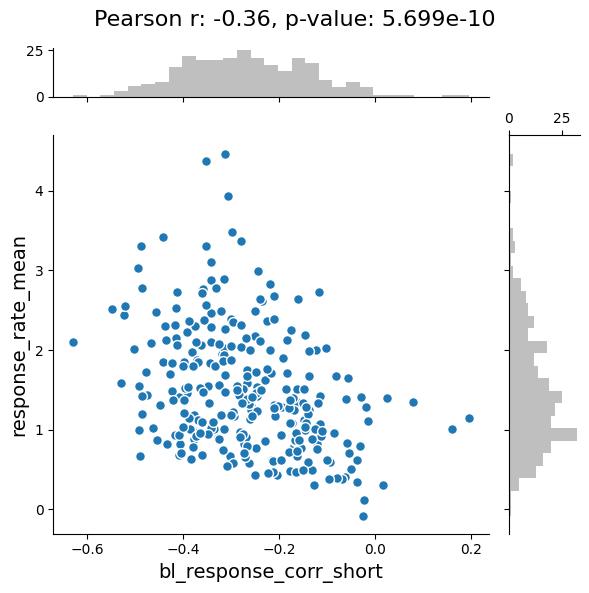

In [17]:
# joint plot between x and y
x_val = 'bl_response_corr_short'
y_val = 'response_rate_mean'
mask = features_combined['be_filter'].values & (features_combined['pc_1'].values<0.5)
# Create JointGrid
g = sns.JointGrid(data=features_combined[mask], x=x_val, y=y_val)
g.plot_joint(sns.scatterplot, alpha=1, edgecolor='white', linewidth=1, s=50)
g.ax_joint.set_xlabel(x_val, fontsize=14)
g.ax_joint.set_ylabel(y_val, fontsize=14)
# Add histograms for x and y axes
x_bins = np.linspace(features_combined[mask][x_val].min(), features_combined[mask][x_val].max(), 30)
y_bins = np.linspace(features_combined[mask][y_val].min(), features_combined[mask][y_val].max(), 30)
g.ax_marg_x.hist(features_combined[mask][x_val], bins=x_bins, color='gray', alpha=0.5, edgecolor='none')
g.ax_marg_y.hist(features_combined[mask][y_val], bins=y_bins, color='gray', alpha=0.5, edgecolor='none', orientation='horizontal')
g.ax_marg_y.set_axis_on()
g.ax_marg_y.spines["top"].set_visible(True)
g.ax_marg_y.tick_params(
    top=True,
    labeltop=True
)
g.ax_marg_x.set_axis_on()
g.ax_marg_x.spines["left"].set_visible(True)
g.ax_marg_x.tick_params(
    left=True,
    labelleft=True
)

# compute correlation and add to title
corr_coef, p_value = pearsonr(features_combined[mask][x_val], features_combined[mask][y_val])
g.fig.suptitle(f'Pearson r: {corr_coef:.2f}, p-value: {p_value:.3e}', fontsize=16)
plt.tight_layout()
save_panels(fig, target_folder, f'joint_plot_{x_val}_{y_val}_{criteria_name}', ['Figure4h'], exts=('svg',), dpi=300, bbox_inches='tight')
# ---- panel CSV (rule 1 scatter) ----
_m = features_combined['be_filter'].values & (features_combined['pc_1'].values < 0.5)
save_panel_csv(columns_to_df(**{x_val: features_combined[x_val][_m].values, y_val: features_combined[y_val][_m].values}), target_folder, f'joint_plot_{x_val}_{y_val}_{criteria_name}', ['Figure4h'])

##Figure4h##

## Firing Rate and Burst Property Analysis

Analyze baseline and response firing rates, correlations between baseline and response activity, and examine burst properties through ACG fit parameters. Create joint plots and histograms of key features.

## Plot Distribution in Space

This section visualizes the spatial distribution of units and their properties across the brain in Common Coordinate Framework (CCF) space. It creates 3D plots showing where recorded neurons are located anatomically and how their properties vary across different brain regions.

## Linear Regression Models

Fit OLS regression models to examine how intrinsic electrophysiological properties predict behavioral tuning metrics (outcome vs action coding). Perform feature selection and model comparison.

## Spatial Distribution Analysis

Analyze spatial dependence of electrophysiological features across brain regions using KNN cross-validation and linear trend analysis. Visualize features in CCF space and perform multiple comparison correction.

## Canonical Correlation Analysis (CCA)

This section begins a series of CCA analyses to examine relationships between different feature sets. CCA identifies linear combinations of variables from two datasets that are maximally correlated, revealing how different types of neural properties co-vary. The following sections perform CCA on: (1) spatial location, (2) waveform features, and (3) behavioral tuning.

## Canonical Correlation Analysis - CCF Space

Perform CCA between electrophysiological features and anatomical location (CCF coordinates). Bootstrap confidence intervals, visualize CCA components in brain space, and examine relationship between CCA scores and ACG profiles.

## Shuffling Control Analysis

Perform permutation tests to assess the statistical significance of CCA results. By randomly shuffling the correspondence between feature sets and re-computing CCA, we can determine whether the observed correlations are greater than expected by chance. This provides confidence intervals and p-values for the canonical correlations.

## Compare with Waveform Features

This section transitions to examining how action potential waveform characteristics relate to other electrophysiological properties. Waveform features (e.g., peak-to-trough ratio, half-width, repolarization slope) can distinguish different cell types and may correlate with firing rate properties and behavioral tuning.

In [18]:
# features_wf = wf_combined_features.columns.to_list()
# features_wf.remove('session')
# features_wf.remove('unit_id')
# features_wf.remove('wf')
# # features_wf.remove('gmm_label')
# # features_wf.remove('kmeans_label')
# # features_wf.remove('gmm_conf')
# features_wf.remove('y_loc')
# # features_wf.remove('probe')
# features_wf.remove('peak')
# features_wf.remove('amp')

## Canonical Correlation Analysis - Waveform Features

Perform CCA between waveform features and basic ephys properties. Bootstrap confidence intervals and visualize relationships between waveform-derived cell types and firing properties.

## Compare with Basic Properties

This section examines relationships between waveform-derived features and fundamental electrophysiological properties such as baseline firing rate, response modulation, and burst characteristics. Understanding these relationships helps link cell-type identity (inferred from waveforms) to functional properties.

## Canonical Correlation Analysis - Behavioral Tuning

Perform CCA between behavioral tuning metrics and basic ephys properties. Examine how intrinsic properties relate to behavioral coding and visualize ACG profiles binned by CCA scores.